In [1]:
# ============================================================
# 02_TRAIN_AND_INFER: FINETUNE YOLO + SUBMISSION
# ============================================================
!pip install -q "protobuf~=3.20.0" ultralytics==8.3.221

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 12.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
grpcio-tools 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.
google-cloud-vision 3.15.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
onnx 1.22.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
google-cloud-videointelligence 2.20.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.26 requires protobuf>=5.29.5, but y

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda
TTA: True | MultiScale Ref: True
Weights: YOLO=0.4, Siamese=0.3, Color=0.3
Temporal: max_gap=5, min_seg=3
START INFERENCE | Weights: YOLO=0.4, Siam=0.3, Color=0.3
Loaded Siamese Model


  0%|          | 0/6 [00:00<?, ?it/s]

  [BlackBox_0] ST-IoU: 0.6014 | Frames detected: 1459
  [BlackBox_1] ST-IoU: 0.7656 | Frames detected: 770
  [CardboardBox_0] ST-IoU: 0.6109 | Frames detected: 1107
  [CardboardBox_1] ST-IoU: 0.7918 | Frames detected: 1733
  [LifeJacket_0] ST-IoU: 0.7470 | Frames detected: 2499
  [LifeJacket_1] ST-IoU: 0.6860 | Frames detected: 2060

DONE. Mean ST-IoU Score: 0.700454
Results saved to: predictions.json

Per-video breakdown:
  BlackBox_0                    : 0.6014
  BlackBox_1                    : 0.7656
  CardboardBox_0                : 0.6109
  CardboardBox_1                : 0.7918
  LifeJacket_0                  : 0.7470
  LifeJacket_1                  : 0.6860

VISUALIZING SAMPLE RESULTS

Video: CardboardBox_0 | Frames: [809, 4439, 5132]


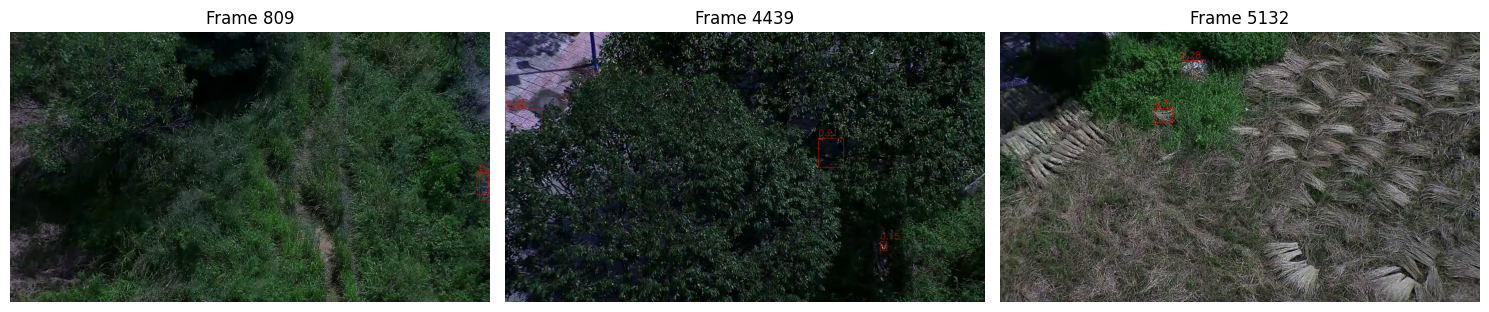


Video: BlackBox_0 | Frames: [1781, 2108, 3763]


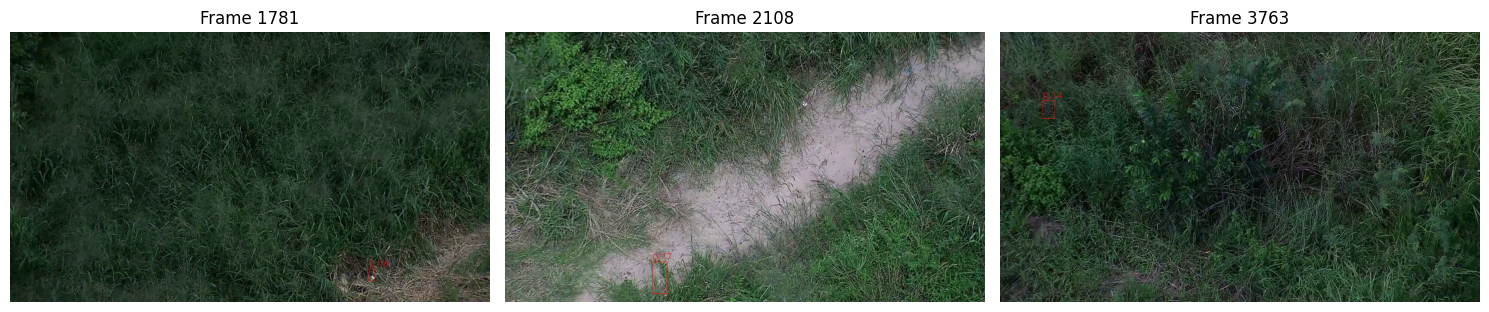


Video: LifeJacket_1 | Frames: [503, 1201, 1423]


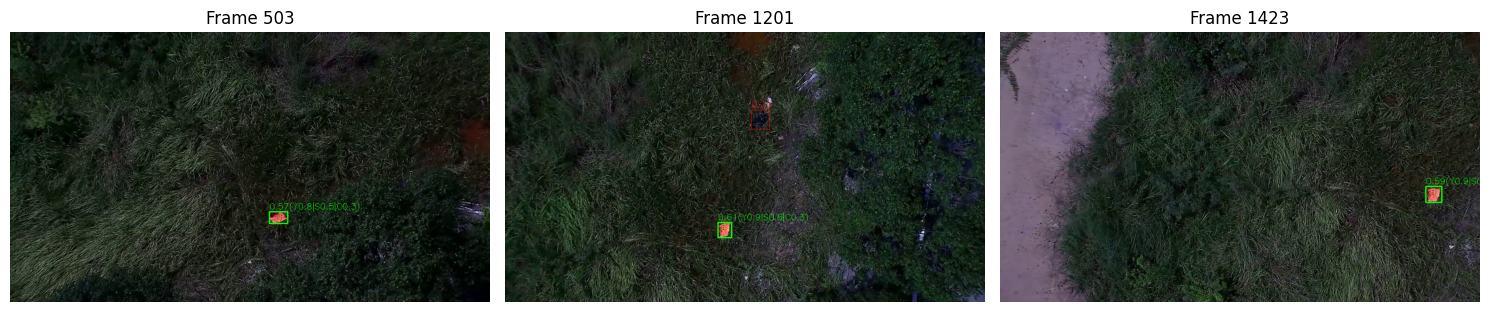

In [2]:
# ==============================================================================
# SPRINT 1 – IMPROVED INFERENCE SCRIPT
# Thay thế cell chính trong 06_inference_main.ipynb
#
# Các cải tiến so với baseline:
#   [A] Temporal smoothing parameters được tune tốt hơn (max_gap=5, min_seg=3)
#   [B] YOLO TTA (augment=True) – detect tốt hơn cho small objects
#   [C] Multi-scale reference embedding – bridge domain gap tốt hơn
#   [D] Per-video ST-IoU logging để debug dễ hơn
# ==============================================================================

# --- 1. IMPORTS & CONFIGURATION ---
import os
import json
import random
import cv2
import numpy as np
from PIL import Image
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import mobilenet_v3_small
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ================= CẤU HÌNH ĐƯỜNG DẪN (SỬA Ở ĐÂY) =================
TEST_DATA_DIR      = '/kaggle/input/datasets/tunphmnguynanh/data-gannhantay-zalo/public_test_remake_full/public_test_remake_full/samples'
GT_ANN_PATH        = '/kaggle/input/datasets/tunphmnguynanh/data-gannhantay-zalo/public_test_remake_full/public_test_remake_full/annotations/drone_annotations.json'
OUTPUT_FILE        = 'predictions.json'

YOLO_MODEL_PATH    = '/kaggle/input/datasets/phamnguyenanhtuan/weight-best-syn/yolo_drone_700.pt'
SIAMESE_MODEL_PATH = '/kaggle/input/datasets/phamnguyenanhtuan/weight-best-syn/siamese_mobilenet_best_1.pth'

# ======================== [SPRINT 1] TUNED CONFIG ========================
CONFIDENCE_THRESHOLD = 0.05
MATCHING_THRESHOLD   = 0.45
YOLO_ONLY_THRESHOLD  = 0.2

WEIGHT_YOLO    = 0.4
WEIGHT_SIAMESE = 0.3
WEIGHT_COLOR   = 0.3

# [SPRINT 1-B] TTA: Test-Time Augmentation
USE_TTA = True

# [SPRINT 1-C] Multi-scale reference embedding
USE_MULTISCALE_REF = True
REF_SCALES = [224, 112, 56]

# [SPRINT 1-A] Temporal smoothing – tuned params
TEMPORAL_MAX_GAP = 5
TEMPORAL_MIN_SEG = 3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"TTA: {USE_TTA} | MultiScale Ref: {USE_MULTISCALE_REF}")
print(f"Weights: YOLO={WEIGHT_YOLO}, Siamese={WEIGHT_SIAMESE}, Color={WEIGHT_COLOR}")
print(f"Temporal: max_gap={TEMPORAL_MAX_GAP}, min_seg={TEMPORAL_MIN_SEG}")

# --- 2. MODEL ---

class SiameseMobileNet(nn.Module):
    def __init__(self, embedding_dim=576):
        super(SiameseMobileNet, self).__init__()
        full_model = mobilenet_v3_small(weights=None)
        self.features = full_model.features
        self.projection = nn.Sequential(
            nn.Linear(embedding_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 128)
        )

    def forward(self, x):
        x = self.features(x)
        x = F.adaptive_avg_pool2d(x, (1, 1)).flatten(1)
        x = self.projection(x)
        return F.normalize(x, p=2, dim=1)

def get_inference_transforms(size=224):
    return transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

# --- 3. HELPERS ---

def load_reference_embeddings(video_folder, model, base_transform):
    """
    [SPRINT 1-C] Multi-scale reference embedding.
    Encode ref images tai 3 scales [224, 112, 56] roi average.
    Scale nho simulate DroneDegradation → bridge domain gap.
    """
    obj_dir = os.path.join(TEST_DATA_DIR, video_folder, "object_images")
    if not os.path.exists(obj_dir):
        return None

    img_paths = sorted([
        os.path.join(obj_dir, f) for f in os.listdir(obj_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    if not img_paths:
        return None

    all_tensors = []
    scales_to_use = REF_SCALES if USE_MULTISCALE_REF else [224]
    transform_224 = get_inference_transforms(size=224)

    for p in img_paths:
        img = cv2.imread(p)
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(img_rgb)

        for scale in scales_to_use:
            if scale != 224:
                # Downscale then NEAREST upsample = DroneDegradation effect
                small = pil_img.resize((scale, scale), Image.BILINEAR)
                pil_input = small.resize((224, 224), Image.NEAREST)
            else:
                pil_input = pil_img
            all_tensors.append(transform_224(pil_input))

    if not all_tensors:
        return None

    batch = torch.stack(all_tensors).to(DEVICE)
    with torch.no_grad():
        embs = model(batch)
        mean_emb = torch.mean(embs, dim=0, keepdim=True)
        mean_emb = F.normalize(mean_emb, p=2, dim=1)

    return mean_emb

def compute_hs_histogram(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array([0, 30, 30]), np.array([180, 255, 255]))
    hist = cv2.calcHist([hsv], [0, 1], mask, [30, 32], [0, 180, 0, 256])
    cv2.normalize(hist, hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
    return hist

def load_reference_histogram(video_folder):
    obj_dir = os.path.join(TEST_DATA_DIR, video_folder, "object_images")
    if not os.path.exists(obj_dir):
        return None
    img_paths = [os.path.join(obj_dir, f) for f in os.listdir(obj_dir)
                 if f.endswith(('.jpg', '.png'))]
    agg_hist = None
    for p in img_paths:
        img = cv2.imread(p)
        if img is None:
            continue
        hist = compute_hs_histogram(img)
        agg_hist = hist if agg_hist is None else agg_hist + hist
    if agg_hist is not None:
        cv2.normalize(agg_hist, agg_hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
    return agg_hist

def calculate_color_score(crop_img, ref_hist):
    if ref_hist is None or crop_img is None or crop_img.size == 0:
        return 0.0
    crop_hist = compute_hs_histogram(crop_img)
    return max(0.0, cv2.compareHist(ref_hist, crop_hist, cv2.HISTCMP_CORREL))

# --- 4. EVALUATION ---

def load_gt_annotations(gt_path):
    if not os.path.exists(gt_path):
        return {}
    with open(gt_path, 'r') as f:
        records = json.load(f)
    gt_map = {}
    for rec in records:
        vid = rec.get("video_id")
        if not vid:
            continue
        frame2bbox = {}
        for interval in rec.get("annotations", []):
            for b in interval.get("bboxes", []):
                frame2bbox[int(b["frame"])] = [int(b["x1"]), int(b["y1"]),
                                               int(b["x2"]), int(b["y2"])]
        gt_map[vid] = frame2bbox
    return gt_map

def iou_box(b1, b2):
    ix1, iy1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    ix2, iy2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area1 = max(0, b1[2] - b1[0]) * max(0, b1[3] - b1[1])
    area2 = max(0, b2[2] - b2[0]) * max(0, b2[3] - b2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0

def compute_st_iou_video(gt_frames, pred_frames):
    inter = set(gt_frames.keys()) & set(pred_frames.keys())
    union = set(gt_frames.keys()) | set(pred_frames.keys())
    if not union:
        return 0.0
    return sum(iou_box(gt_frames[f], pred_frames[f]) for f in inter) / len(union)

def visualize_sample_results(all_predictions, debug_info, num_videos=3, num_frames_per_video=3):
    print("\n" + "="*50 + "\nVISUALIZING SAMPLE RESULTS\n" + "="*50)
    valid_preds = [p for p in all_predictions
                   if len(p["detections"]) > 0 and len(p["detections"][0]["bboxes"]) > 0]
    if not valid_preds:
        print("Khong co video nao co detection.")
        return
    selected = random.sample(valid_preds, min(len(valid_preds), num_videos))
    for pred in selected:
        vid_id = pred["video_id"]
        video_info = debug_info.get(vid_id, {})
        if not video_info:
            continue
        frame_indices = sorted(list(video_info.keys()))
        chosen_frames = sorted(random.sample(frame_indices, min(len(frame_indices), num_frames_per_video)))
        print(f"\nVideo: {vid_id} | Frames: {chosen_frames}")
        vid_path = os.path.join(TEST_DATA_DIR, vid_id, "drone_video.mp4")
        cap = cv2.VideoCapture(vid_path)
        plt.figure(figsize=(5 * len(chosen_frames), 5))
        for i, f_idx in enumerate(chosen_frames):
            cap.set(cv2.CAP_PROP_POS_FRAMES, f_idx)
            ret, frame = cap.read()
            if not ret:
                continue
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            for cand in video_info.get(f_idx, []):
                x1, y1, x2, y2 = map(int, cand["bbox"])
                fs = cand["final_score"]
                sc = cand.get("scores", (0, 0, 0))
                color = (0, 255, 0) if cand["is_best"] else (255, 0, 0)
                label = f"{fs:.2f}(Y{sc[0]:.1f}|S{sc[1]:.1f}|C{sc[2]:.1f})" if cand["is_best"] else f"{fs:.2f}"
                cv2.rectangle(frame_rgb, (x1, y1), (x2, y2), color, 2 if cand["is_best"] else 1)
                cv2.putText(frame_rgb, label, (x1, max(15, y1 - 5)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 1)
            plt.subplot(1, len(chosen_frames), i + 1)
            plt.imshow(frame_rgb)
            plt.axis("off")
            plt.title(f"Frame {f_idx}")
        plt.tight_layout()
        plt.show()
        cap.release()

# --- 5. [SPRINT 1-A] IMPROVED TEMPORAL SMOOTHING ---

def temporal_smooth_detections(frame_best, max_frame_idx,
                               min_seg_len=TEMPORAL_MIN_SEG,
                               max_gap=TEMPORAL_MAX_GAP):
    """
    [SPRINT 1-A] Improved temporal smoothing.

    Changes vs baseline:
      - max_gap: 4 -> 5  (tolerate 5-frame gaps)
      - min_seg_len: 5 -> 3  (keep shorter segments, fewer false negatives)
      - int(round()) for output coordinates (vs int() which truncates)

    Logic:
      1. Fill gaps <= max_gap with linear interpolation of bbox
      2. Remove isolated segments < min_seg_len (noise suppression)
    """
    T = max_frame_idx + 1
    det = [None] * T

    for f, info in frame_best.items():
        if 0 <= f < T:
            det[f] = info

    # STEP 1: Fill gaps with linear interpolation
    for i in range(T):
        if det[i] is not None:
            next_idx = -1
            for k in range(1, max_gap + 2):
                if i + k < T and det[i + k] is not None:
                    next_idx = i + k
                    break
            # Only fill if gap size <= max_gap
            gap_size = next_idx - i - 1 if next_idx != -1 else 999
            if 0 < gap_size <= max_gap:
                b1, s1 = det[i]['bbox'], det[i]['score']
                b2, s2 = det[next_idx]['bbox'], det[next_idx]['score']
                steps = next_idx - i
                for step in range(1, steps):
                    alpha = step / steps
                    ibox = [b1[j] * (1 - alpha) + b2[j] * alpha for j in range(4)]
                    iscore = s1 * (1 - alpha) + s2 * alpha
                    det[i + step] = {'bbox': ibox, 'score': iscore}

    # STEP 2: Remove short segments
    i = 0
    while i < T:
        if det[i] is not None:
            j = i
            while j + 1 < T and det[j + 1] is not None:
                j += 1
            if (j - i + 1) < min_seg_len:
                for k in range(i, j + 1):
                    det[k] = None
            i = j + 1
        else:
            i += 1

    # Output
    out = []
    for f in range(T):
        if det[f] is not None:
            x1, y1, x2, y2 = det[f]['bbox']
            out.append({
                "frame": f,
                "x1": int(round(x1)), "y1": int(round(y1)),
                "x2": int(round(x2)), "y2": int(round(y2))
            })
    return out

# --- 6. MAIN ---

def main():
    print(f"START INFERENCE | Weights: YOLO={WEIGHT_YOLO}, Siam={WEIGHT_SIAMESE}, Color={WEIGHT_COLOR}")

    yolo = YOLO(YOLO_MODEL_PATH)

    siam = SiameseMobileNet().to(DEVICE)
    use_siam = False
    if os.path.exists(SIAMESE_MODEL_PATH):
        siam.load_state_dict(torch.load(SIAMESE_MODEL_PATH, map_location=DEVICE))
        siam.eval()
        use_siam = True
        print("Loaded Siamese Model")
    else:
        print("Siamese weights not found - Using YOLO Only fallback")

    gt_map = load_gt_annotations(GT_ANN_PATH)
    base_transform = get_inference_transforms(size=224)

    all_preds = []
    st_iou_per_video = {}
    debug_info = {}

    try:
        video_folders = sorted([
            f for f in os.listdir(TEST_DATA_DIR)
            if os.path.isdir(os.path.join(TEST_DATA_DIR, f))
        ])
    except Exception:
        print("Error: TEST_DATA_DIR not found")
        return

    for vid_id in tqdm(video_folders):
        vid_path = os.path.join(TEST_DATA_DIR, vid_id, "drone_video.mp4")
        if not os.path.exists(vid_path):
            all_preds.append({"video_id": vid_id, "detections": []})
            continue

        # References
        ref_emb = load_reference_embeddings(vid_id, siam, base_transform) if use_siam else None
        ref_hist = load_reference_histogram(vid_id)

        # [SPRINT 1-B] Predict with TTA
        results = yolo.predict(
            vid_path,
            stream=True,
            conf=CONFIDENCE_THRESHOLD,
            verbose=False,
            augment=USE_TTA,
        )

        frame_best = {}
        frame_debug = {}
        max_frame_idx = -1

        for f_idx, res in enumerate(results):
            max_frame_idx = max(max_frame_idx, f_idx)
            if not res.boxes:
                continue

            boxes = res.boxes.xyxy.cpu().numpy()
            confs = res.boxes.conf.cpu().numpy()
            orig_img = res.orig_img
            h, w = orig_img.shape[:2]
            pil_img = Image.fromarray(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))

            cand_tensors = []
            cand_bgrs = []
            valid_indices = []

            for i, box in enumerate(boxes):
                x1, y1, x2, y2 = map(int, box)
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(w, x2), min(h, y2)
                if x2 <= x1 + 5 or y2 <= y1 + 5:
                    continue
                valid_indices.append(i)
                cand_tensors.append(base_transform(pil_img.crop((x1, y1, x2, y2))))
                cand_bgrs.append(orig_img[y1:y2, x1:x2])

            if not cand_tensors:
                continue

            siam_scores = np.zeros(len(cand_tensors))
            color_scores = np.zeros(len(cand_tensors))

            if ref_emb is not None:
                with torch.no_grad():
                    batch = torch.stack(cand_tensors).to(DEVICE)
                    feats = siam(batch)
                    dists = torch.cdist(ref_emb, feats).cpu().numpy()[0]
                    siam_scores = np.maximum(0, 1.0 - dists / 2.0)

            if ref_hist is not None:
                for k, crop_bgr in enumerate(cand_bgrs):
                    color_scores[k] = calculate_color_score(crop_bgr, ref_hist)

            best_score = -1.0
            best_box = None
            candidates_info = []

            for k, idx in enumerate(valid_indices):
                yolo_s = float(confs[idx])
                siam_s = float(siam_scores[k])
                col_s  = float(color_scores[k])

                w_y = WEIGHT_YOLO
                w_s = WEIGHT_SIAMESE if ref_emb is not None else 0.0
                w_c = WEIGHT_COLOR if ref_hist is not None else 0.0
                total_w = w_y + w_s + w_c
                final_score = (w_y * yolo_s + w_s * siam_s + w_c * col_s) / total_w if total_w > 0 else yolo_s

                candidates_info.append({
                    "bbox": boxes[idx].tolist(),
                    "final_score": float(final_score),
                    "scores": (yolo_s, siam_s, col_s),
                    "is_best": False
                })

                if final_score > best_score:
                    best_score = final_score
                    best_box = boxes[idx]

            frame_debug[f_idx] = candidates_info

            thresh = MATCHING_THRESHOLD if (ref_emb is not None) else YOLO_ONLY_THRESHOLD
            if best_box is not None and best_score >= thresh:
                frame_best[f_idx] = {'bbox': best_box.tolist(), 'score': float(best_score)}
                best_box_list = best_box.tolist()
                for ci in frame_debug[f_idx]:
                    if ci["bbox"] == best_box_list:
                        ci["is_best"] = True
                        break

        debug_info[vid_id] = frame_debug

        # [SPRINT 1-A] Temporal smoothing
        final_bboxes = temporal_smooth_detections(frame_best, max_frame_idx) if frame_best else []

        all_preds.append({
            "video_id": vid_id,
            "detections": [{"bboxes": final_bboxes}] if final_bboxes else []
        })

        gt_frames = gt_map.get(vid_id, {})
        pred_frames = {b["frame"]: [b["x1"], b["y1"], b["x2"], b["y2"]] for b in final_bboxes}
        st_iou_per_video[vid_id] = compute_st_iou_video(gt_frames, pred_frames)
        print(f"  [{vid_id}] ST-IoU: {st_iou_per_video[vid_id]:.4f} | Frames detected: {len(final_bboxes)}")

    with open(OUTPUT_FILE, 'w') as f:
        json.dump(all_preds, f, indent=4)

    mean_score = sum(st_iou_per_video.values()) / max(1, len(st_iou_per_video))
    print(f"\nDONE. Mean ST-IoU Score: {mean_score:.6f}")
    print(f"Results saved to: {OUTPUT_FILE}")
    print("\nPer-video breakdown:")
    for vid, score in sorted(st_iou_per_video.items()):
        print(f"  {vid:30s}: {score:.4f}")

    visualize_sample_results(all_preds, debug_info, num_videos=3)

if __name__ == "__main__":
    main()
